# IntelliPulse V3 — Random Forest Baseline

---

## 1 · Experimental Question

Our experiments so far have used **Logistic Regression** — a linear model. Logistic Regression assumes that the log-odds of churn are a linear combination of the features. If the true relationship between features and churn involves nonlinearities or feature interactions (e.g., "fiber-optic internet AND month-to-month contract together increase churn more than either feature alone"), a linear model may underperform.

| Experiment | Model | Threshold | F1 | ROC-AUC |
|------------|-------|-----------|-----|---------|
| V1 | Standard LR | 0.50 | 0.6040 | 0.8421 |
| V2.1 | Standard LR | 0.27 | 0.6214 | 0.8421 |
| V2.2 | Class-weighted LR | 0.50 | 0.6136 | 0.8416 |
| V2.2 | Class-weighted LR | 0.54 (best F1) | 0.6217 | 0.8416 |

**V3 asks:** *Can a Random Forest — a nonlinear, tree-based ensemble — capture patterns that Logistic Regression does not, and improve predictive performance on the same held-out test set?*

### Why Random Forest?

| Property | Benefit |
|----------|---------|
| **Nonlinear** | Can model complex, non-additive relationships between features and churn. |
| **Ensemble** | Averages many decision trees, reducing variance and overfitting. |
| **Feature interactions** | Naturally captures interactions (e.g., short tenure + fiber optic). |
| **No scaling required** | Tree-based models are invariant to monotonic feature transformations. |
| **Feature importance** | Provides built-in feature importance scores. |
| **Robust baseline** | Competitive on tabular data with minimal tuning. |

### What V3 does NOT do

- No hyperparameter tuning (GridSearchCV, RandomizedSearchCV).
- No class weighting — we want a clean standard-RF vs standard-LR comparison first.
- No threshold optimisation — we evaluate at 0.50 for a fair comparison with V1.
- No SMOTE or other resampling techniques.

---

## 2 · Imports and Configuration

In [1]:
import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

# ── Configuration ────────────────────────────────────────────────────
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"

print(f"Project root : {PROJECT_ROOT}")
print(f"Random state : {RANDOM_STATE}")

Project root : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse
Random state : 42


---

## 3 · Load and Prepare Data (Same as V1)

We replicate the **exact same** data loading, cleaning, feature definitions, and train/test split used in V1. This ensures a fair comparison — any performance difference between V1 and V3 is due solely to the model, not to a different split or different features.

In [2]:
# ── Load raw data ─────────────────────────────────────────────────────
assert RAW_DATA_PATH.exists(), f"Dataset not found at {RAW_DATA_PATH}"
df_raw = pd.read_csv(RAW_DATA_PATH)
df = df_raw.copy()

# ── Fix TotalCharges (same as V1) ────────────────────────────────────
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

# ── Column definitions (identical to V1) ─────────────────────────────
ID_COL = "customerID"
TARGET_COL = "Churn"

NUMERICAL_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
CATEGORICAL_FEATURES = [
    "gender", "Partner", "Dependents",
    "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

# ── Separate X and y ─────────────────────────────────────────────────
X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1}).astype(int)

# ── Same train/test split as V1 ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"Train churn rate: {y_train.mean():.4f}")
print(f"Test churn rate : {y_test.mean():.4f}")

Training set : 5,634 rows
Test set     : 1,409 rows
Train churn rate: 0.2654
Test churn rate : 0.2654


In [3]:
# ── Load prior experiment metrics for comparison ─────────────────────
with open(METRICS_DIR / "baseline_v1.json") as f:
    v1_metrics = json.load(f)

with open(METRICS_DIR / "threshold_analysis_v2_1.json") as f:
    v2_1_data = json.load(f)
v2_1_metrics = v2_1_data["provisional_metrics"]
v2_1_threshold = v2_1_data["provisional_threshold"]

with open(METRICS_DIR / "class_weighted_v2_2.json") as f:
    v2_2_data = json.load(f)
v2_2_metrics_050 = v2_2_data["metrics_at_050"]
v2_2_metrics_best = v2_2_data["metrics_at_best_f1"]
v2_2_best_threshold = v2_2_data["best_f1_threshold"]

print("Prior metrics loaded:")
print(f"  V1    — F1: {v1_metrics['f1_score']:.4f}, ROC-AUC: {v1_metrics['roc_auc']:.4f}")
print(f"  V2.1  — F1: {v2_1_metrics['f1']:.4f} (threshold={v2_1_threshold})")
print(f"  V2.2  — F1: {v2_2_metrics_050['f1']:.4f} (@ 0.50), "
      f"{v2_2_metrics_best['f1']:.4f} (@ {v2_2_best_threshold})")

Prior metrics loaded:
  V1    — F1: 0.6040, ROC-AUC: 0.8421
  V2.1  — F1: 0.6214 (threshold=0.27)
  V2.2  — F1: 0.6136 (@ 0.50), 0.6217 (@ 0.54)


---

## 4 · Preprocessing Pipeline

### Why reuse the same preprocessing?

We use the **same** `ColumnTransformer` structure as V1 — numerical features through `SimpleImputer` → `StandardScaler`, and categorical features through `SimpleImputer` → `OneHotEncoder`.

**A note on scaling:** Random Forest does not *require* feature scaling — trees make splits based on thresholds, and scaling doesn't change the rank-order of values within a feature. However, using the same preprocessing pipeline has two important advantages:

1. **Fair comparison:** Any performance difference is attributable to the model, not to different preprocessing.
2. **Operational consistency:** All models in our experiment pipeline consume the same feature representation, simplifying future deployment.

The scaling is harmless for Random Forest (a monotonic transform doesn't affect tree splits) but ensures comparability.

In [4]:
# ── Build preprocessing pipeline (identical to V1) ───────────────────
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, NUMERICAL_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

print("Preprocessor defined (identical to V1).")

Preprocessor defined (identical to V1).


---

## 5 · Build the V3 Random Forest Pipeline

We use a **reasonable, untuned** baseline configuration:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_estimators` | 300 | Enough trees for stable predictions; diminishing returns beyond ~200–500 for most tabular datasets. |
| `random_state` | 42 | Reproducibility — same seed used throughout the project. |
| `n_jobs` | -1 | Use all CPU cores for faster training. |
| `class_weight` | None (default) | We want a clean standard-RF vs standard-LR comparison. Class weighting can be investigated separately. |

No hyperparameter tuning is performed. This is deliberately a *baseline* Random Forest — we want to know what RF achieves "out of the box" before investing in optimisation.

In [5]:
# ── V3 pipeline: same preprocessing + Random Forest ──────────────────
model_v3 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

print("V3 pipeline constructed.")
print(f"  Classifier: {model_v3.named_steps['classifier']}")

V3 pipeline constructed.
  Classifier: RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)


---

## 6 · Train V3

We fit the Random Forest pipeline on the **training set only**. The test set is not used during training — it remains held out for evaluation.

The `Pipeline` ensures no data leakage: the preprocessor is fitted only on training data, and the classifier is trained only on the transformed training data.

In [6]:
model_v3.fit(X_train, y_train)

print("✓ V3 Random Forest trained on training set.")
print(f"  Training samples: {len(y_train):,}")
n_features = model_v3.named_steps["preprocessor"].transform(X_train[:1]).shape[1]
print(f"  Features after encoding: {n_features}")
print(f"  Trees in ensemble: {model_v3.named_steps['classifier'].n_estimators}")

✓ V3 Random Forest trained on training set.
  Training samples: 5,634
  Features after encoding: 45
  Trees in ensemble: 300


---

## 7 · Evaluate V3 at Default Threshold (0.50)

We evaluate with the standard 0.50 threshold for a direct comparison with V1.

In [7]:
# ── Predictions at threshold 0.50 ────────────────────────────────────
y_pred_v3 = model_v3.predict(X_test)
y_prob_v3 = model_v3.predict_proba(X_test)[:, 1]

# ── Metrics ──────────────────────────────────────────────────────────
acc_v3  = accuracy_score(y_test, y_pred_v3)
prec_v3 = precision_score(y_test, y_pred_v3)
rec_v3  = recall_score(y_test, y_pred_v3)
f1_v3   = f1_score(y_test, y_pred_v3)
auc_v3  = roc_auc_score(y_test, y_prob_v3)

# Confusion matrix
cm_v3 = confusion_matrix(y_test, y_pred_v3)
tn_v3, fp_v3, fn_v3, tp_v3 = cm_v3.ravel()

v3_metrics_050 = {
    "model": "RandomForest_V3",
    "threshold": 0.50,
    "accuracy": round(acc_v3, 4),
    "precision": round(prec_v3, 4),
    "recall": round(rec_v3, 4),
    "f1_score": round(f1_v3, 4),
    "roc_auc": round(auc_v3, 4),
    "tp": int(tp_v3), "fp": int(fp_v3),
    "fn": int(fn_v3), "tn": int(tn_v3),
}

print("=" * 50)
print("  V3 — Test Set Evaluation @ Threshold 0.50")
print("=" * 50)
print(f"  Accuracy  : {acc_v3:.4f}")
print(f"  Precision : {prec_v3:.4f}")
print(f"  Recall    : {rec_v3:.4f}")
print(f"  F1-score  : {f1_v3:.4f}")
print(f"  ROC-AUC   : {auc_v3:.4f}")
print("=" * 50)

  V3 — Test Set Evaluation @ Threshold 0.50
  Accuracy  : 0.7771
  Precision : 0.6007
  Recall    : 0.4786
  F1-score  : 0.5327
  ROC-AUC   : 0.8206


### Classification report

In [8]:
print(classification_report(y_test, y_pred_v3,
                            target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



### Confusion matrix

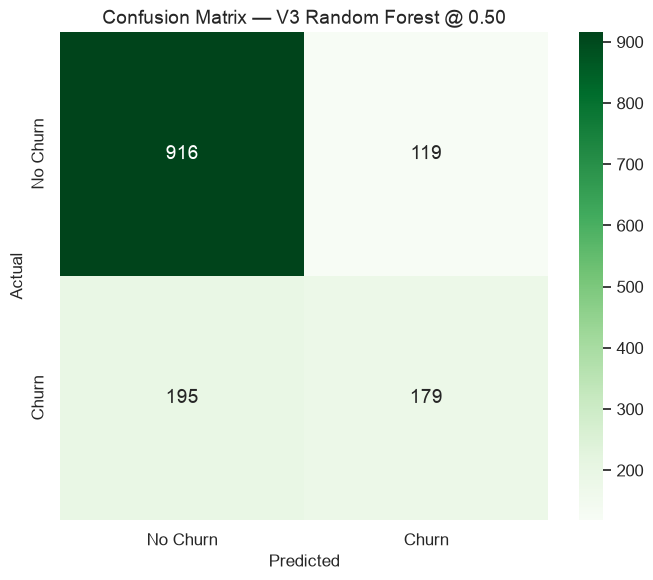

True Negatives  (correct No Churn) : 916
False Positives (false alarms)     : 119
False Negatives (MISSED churners)  : 195
True Positives  (caught churners)  : 179


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_v3, annot=True, fmt="d", cmap="Greens", ax=ax,
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"],
            annot_kws={"size": 14})
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — V3 Random Forest @ 0.50")
plt.tight_layout()
plt.show()

print(f"True Negatives  (correct No Churn) : {tn_v3}")
print(f"False Positives (false alarms)     : {fp_v3}")
print(f"False Negatives (MISSED churners)  : {fn_v3}")
print(f"True Positives  (caught churners)  : {tp_v3}")

---

## 8 · V1 vs V3 Comparison (Both @ Threshold 0.50)

This is the core comparison: **Standard Logistic Regression vs Standard Random Forest**, both evaluated at the default 0.50 threshold, on the exact same test set, with the same preprocessing.

In [10]:
# ── V1 confusion matrix ──────────────────────────────────────────────
model_v1 = joblib.load(MODEL_DIR / "churn_baseline_v1.joblib")
y_pred_v1 = model_v1.predict(X_test)
cm_v1 = confusion_matrix(y_test, y_pred_v1)
tn_v1, fp_v1, fn_v1, tp_v1 = cm_v1.ravel()

comparison_v1_v3 = pd.DataFrame({
    "Metric": [
        "Model", "Threshold",
        "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC",
        "", "True Positives", "False Positives",
        "False Negatives", "True Negatives",
    ],
    "V1 — Logistic Regression": [
        "Standard LR", "0.50",
        f"{v1_metrics['accuracy']:.4f}",
        f"{v1_metrics['precision']:.4f}",
        f"{v1_metrics['recall']:.4f}",
        f"{v1_metrics['f1_score']:.4f}",
        f"{v1_metrics['roc_auc']:.4f}",
        "",
        str(int(tp_v1)), str(int(fp_v1)),
        str(int(fn_v1)), str(int(tn_v1)),
    ],
    "V3 — Random Forest": [
        "Random Forest", "0.50",
        f"{acc_v3:.4f}",
        f"{prec_v3:.4f}",
        f"{rec_v3:.4f}",
        f"{f1_v3:.4f}",
        f"{auc_v3:.4f}",
        "",
        str(int(tp_v3)), str(int(fp_v3)),
        str(int(fn_v3)), str(int(tn_v3)),
    ],
})

print("V1 vs V3 — Side-by-Side Comparison (Both @ 0.50)")
print("=" * 65)
print(comparison_v1_v3.to_string(index=False))

V1 vs V3 — Side-by-Side Comparison (Both @ 0.50)
         Metric V1 — Logistic Regression V3 — Random Forest
          Model              Standard LR      Random Forest
      Threshold                     0.50               0.50
       Accuracy                   0.8055             0.7771
      Precision                   0.6572             0.6007
         Recall                   0.5588             0.4786
       F1-score                   0.6040             0.5327
        ROC-AUC                   0.8421             0.8206
                                                           
 True Positives                      209                179
False Positives                      109                119
False Negatives                      165                195
 True Negatives                      926                916


In [11]:
# ── Delta analysis ────────────────────────────────────────────────────
print("\nChanges from V1 → V3 (both @ threshold 0.50):")
print(f"  Accuracy  : {acc_v3 - v1_metrics['accuracy']:+.4f}"
      f"  {'↑' if acc_v3 > v1_metrics['accuracy'] else '↓'}")
print(f"  Precision : {prec_v3 - v1_metrics['precision']:+.4f}"
      f"  {'↑' if prec_v3 > v1_metrics['precision'] else '↓'}")
print(f"  Recall    : {rec_v3 - v1_metrics['recall']:+.4f}"
      f"  {'↑' if rec_v3 > v1_metrics['recall'] else '↓'}")
print(f"  F1-score  : {f1_v3 - v1_metrics['f1_score']:+.4f}"
      f"  {'↑' if f1_v3 > v1_metrics['f1_score'] else '↓'}")
print(f"  ROC-AUC   : {auc_v3 - v1_metrics['roc_auc']:+.4f}"
      f"  {'↑' if auc_v3 > v1_metrics['roc_auc'] else '↓'}")
print(f"  FN change : {int(fn_v3) - int(fn_v1):+d}  (missed churners)")
print(f"  FP change : {int(fp_v3) - int(fp_v1):+d}  (false alarms)")


Changes from V1 → V3 (both @ threshold 0.50):
  Accuracy  : -0.0284  ↓
  Precision : -0.0565  ↓
  Recall    : -0.0802  ↓
  F1-score  : -0.0713  ↓
  ROC-AUC   : -0.0215  ↓
  FN change : +30  (missed churners)
  FP change : +10  (false alarms)


---

## 9 · Consolidated Comparison — All Experiments

This table shows every experiment we've run, using the actual recorded metrics.

In [12]:
consolidated = pd.DataFrame({
    "Experiment": ["V1", "V2.1", "V2.2 @ 0.50",
                   f"V2.2 @ {v2_2_best_threshold}", "V3"],
    "Model": [
        "Standard LR", "Standard LR", "Class-Weighted LR",
        "Class-Weighted LR", "Random Forest",
    ],
    "Threshold": [
        0.50, v2_1_threshold, 0.50,
        v2_2_best_threshold, 0.50,
    ],
    "Accuracy": [
        v1_metrics["accuracy"],
        v2_1_metrics["accuracy"],
        v2_2_metrics_050["accuracy"],
        v2_2_metrics_best["accuracy"],
        round(acc_v3, 4),
    ],
    "Precision": [
        v1_metrics["precision"],
        v2_1_metrics["precision"],
        v2_2_metrics_050["precision"],
        v2_2_metrics_best["precision"],
        round(prec_v3, 4),
    ],
    "Recall": [
        v1_metrics["recall"],
        v2_1_metrics["recall"],
        v2_2_metrics_050["recall"],
        v2_2_metrics_best["recall"],
        round(rec_v3, 4),
    ],
    "F1": [
        v1_metrics["f1_score"],
        v2_1_metrics["f1"],
        v2_2_metrics_050["f1"],
        v2_2_metrics_best["f1"],
        round(f1_v3, 4),
    ],
    "ROC-AUC": [
        v1_metrics["roc_auc"],
        v1_metrics["roc_auc"],  # same model
        v2_2_metrics_050["roc_auc"],
        v2_2_metrics_best["roc_auc"],  # same model
        round(auc_v3, 4),
    ],
})

print("Consolidated Experiment Comparison")
print("=" * 95)
print(consolidated.to_string(index=False))

Consolidated Experiment Comparison
 Experiment             Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC
         V1       Standard LR       0.50    0.8055     0.6572  0.5588 0.6040   0.8421
       V2.1       Standard LR       0.27    0.7466     0.5149  0.7834 0.6214   0.8421
V2.2 @ 0.50 Class-Weighted LR       0.50    0.7381     0.5043  0.7834 0.6136   0.8416
V2.2 @ 0.54 Class-Weighted LR       0.54    0.7530     0.5238  0.7647 0.6217   0.8416
         V3     Random Forest       0.50    0.7771     0.6007  0.4786 0.5327   0.8206


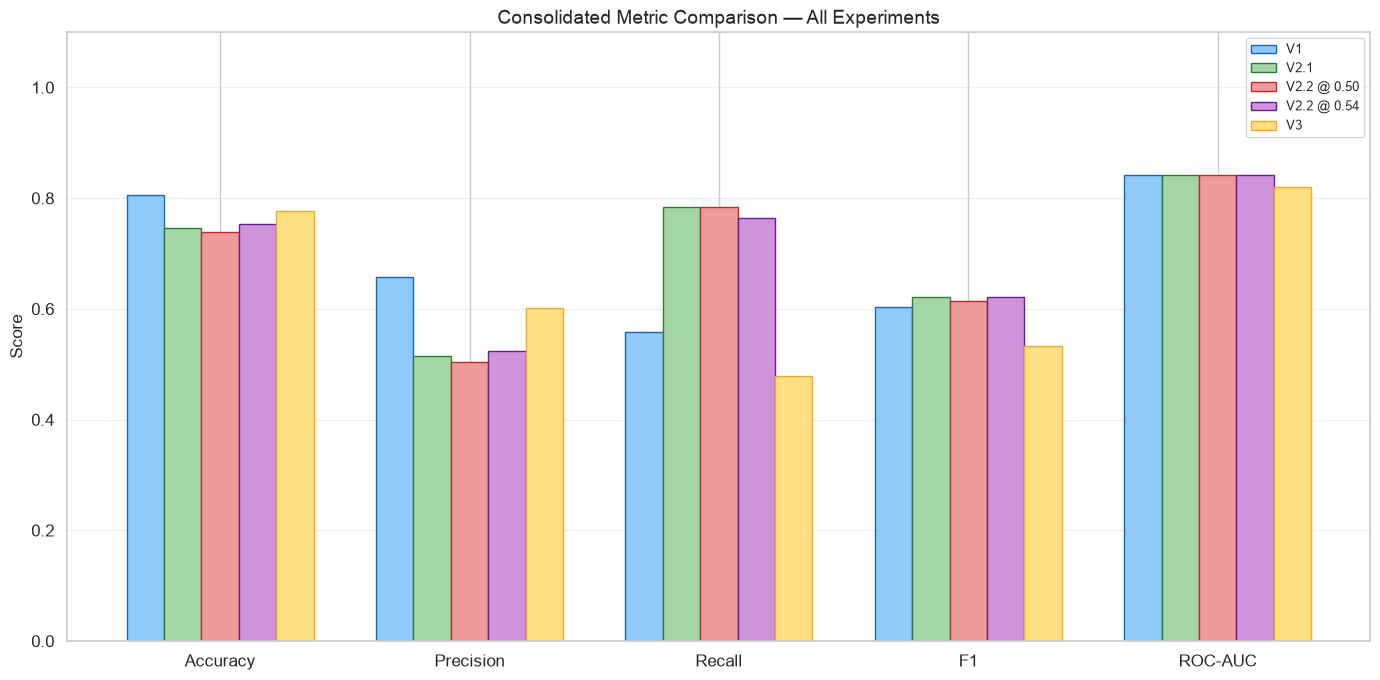

In [13]:
# ── Visual comparison ────────────────────────────────────────────────
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
experiments = consolidated["Experiment"].tolist()

x = np.arange(len(metric_cols))
n_exp = len(experiments)
width = 0.15

colors = ["#90CAF9", "#A5D6A7", "#EF9A9A", "#CE93D8", "#FFE082"]
edge_colors = ["#1565C0", "#2E7D32", "#C62828", "#6A1B9A", "#F9A825"]

fig, ax = plt.subplots(figsize=(14, 7))

for i, exp in enumerate(experiments):
    vals = consolidated.loc[consolidated["Experiment"] == exp, metric_cols].values[0]
    offset = (i - n_exp/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=exp,
                  color=colors[i], edgecolor=edge_colors[i])

ax.set_ylabel("Score")
ax.set_title("Consolidated Metric Comparison — All Experiments")
ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1.10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---

## 10 · Confusion Matrix Interpretation

We compare the confusion matrices of V1 and V3 side-by-side.

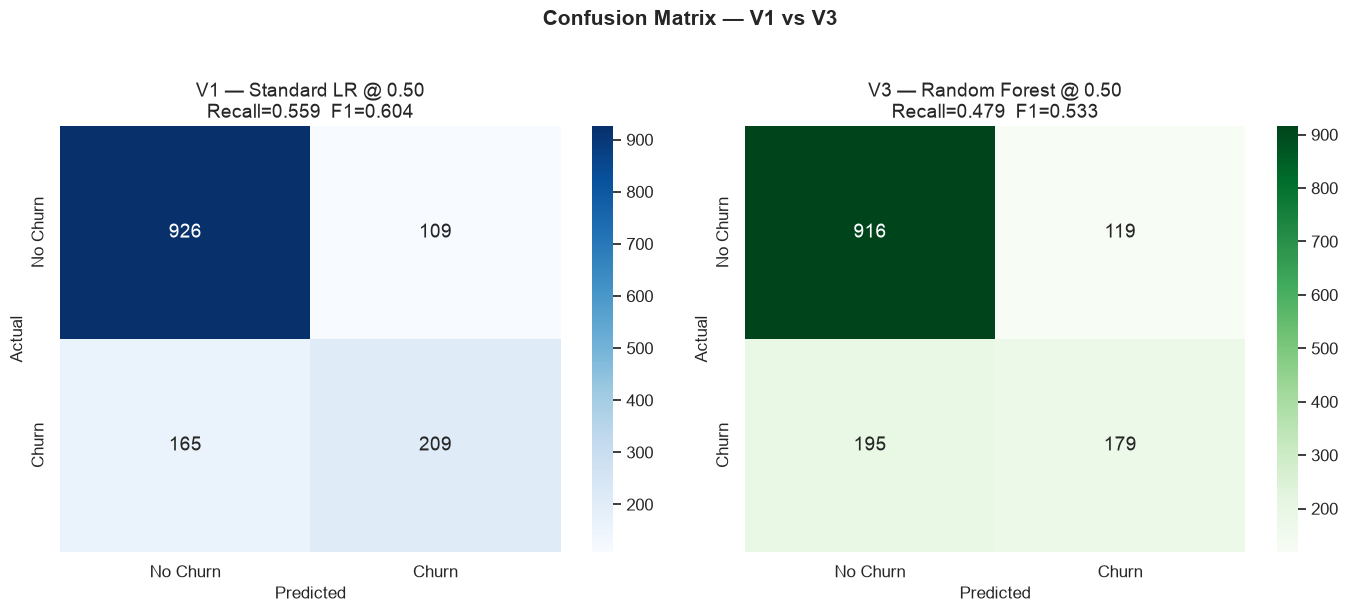

Business impact — V1 → V3:
  Churners caught  : 209 → 179 (Δ -30)
  Churners missed  : 165 → 195 (Δ +30)
  False alarms     : 109 → 119 (Δ +10)
  Correct No Churn : 926 → 916 (Δ -10)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# V1
sns.heatmap(cm_v1, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"],
            annot_kws={"size": 14})
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"V1 — Standard LR @ 0.50\nRecall={v1_metrics['recall']:.3f}  "
                  f"F1={v1_metrics['f1_score']:.3f}")

# V3
sns.heatmap(cm_v3, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"],
            annot_kws={"size": 14})
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(f"V3 — Random Forest @ 0.50\nRecall={rec_v3:.3f}  "
                  f"F1={f1_v3:.3f}")

plt.suptitle("Confusion Matrix — V1 vs V3",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Business impact — V1 → V3:")
print(f"  Churners caught  : {int(tp_v1)} → {int(tp_v3)} (Δ {int(tp_v3)-int(tp_v1):+d})")
print(f"  Churners missed  : {int(fn_v1)} → {int(fn_v3)} (Δ {int(fn_v3)-int(fn_v1):+d})")
print(f"  False alarms     : {int(fp_v1)} → {int(fp_v3)} (Δ {int(fp_v3)-int(fp_v1):+d})")
print(f"  Correct No Churn : {int(tn_v1)} → {int(tn_v3)} (Δ {int(tn_v3)-int(tn_v1):+d})")

### Business meaning

**False Negatives (missed churners):** Each FN is a customer who churns without the company attempting retention — a direct revenue loss. Comparing FN counts between V1 and V3 tells us which model is better at *catching* at-risk customers.

**False Positives (false alarms):** Each FP triggers an unnecessary retention action. This has a cost, but it is typically much smaller than losing a customer. If V3 reduces FN without dramatically increasing FP, that is a net win for the business.

---

## 11 · ROC-AUC Comparison

ROC-AUC measures the model's ability to **rank** customers by churn risk across *all possible thresholds*. A higher ROC-AUC means the model more consistently assigns higher probabilities to actual churners than to non-churners.

| ROC-AUC | Interpretation |
|---------|---------------|
| 0.50 | No discrimination — equivalent to random guessing |
| 0.70–0.80 | Fair discrimination |
| 0.80–0.90 | Good discrimination |
| 0.90+ | Excellent discrimination |

> **Important:** A higher ROC-AUC does not automatically mean the model is "better" for every business objective. A model with slightly lower ROC-AUC but better precision/recall balance at the chosen operating threshold may be preferable. ROC-AUC is a *summary* of performance across all thresholds; the business operates at a specific threshold.

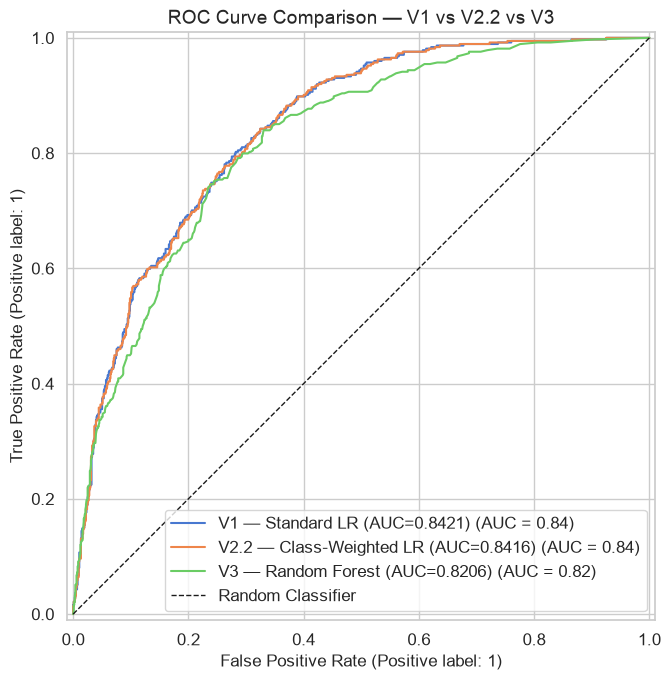

ROC-AUC comparison:
  V1  (Standard LR)       : 0.8421
  V2.2 (Class-Weighted LR): 0.8416
  V3  (Random Forest)     : 0.8206


In [15]:
# ── ROC curves side by side ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
RocCurveDisplay.from_estimator(model_v1, X_test, y_test, ax=ax,
                                name=f"V1 — Standard LR (AUC={v1_metrics['roc_auc']:.4f})")

# Load V2.2 model for ROC comparison
model_v2_2 = joblib.load(MODEL_DIR / "churn_class_weighted_v2_2.joblib")
RocCurveDisplay.from_estimator(model_v2_2, X_test, y_test, ax=ax,
                                name=f"V2.2 — Class-Weighted LR (AUC={v2_2_metrics_050['roc_auc']:.4f})")

RocCurveDisplay.from_estimator(model_v3, X_test, y_test, ax=ax,
                                name=f"V3 — Random Forest (AUC={auc_v3:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
ax.set_title("ROC Curve Comparison — V1 vs V2.2 vs V3")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC comparison:")
print(f"  V1  (Standard LR)       : {v1_metrics['roc_auc']:.4f}")
print(f"  V2.2 (Class-Weighted LR): {v2_2_metrics_050['roc_auc']:.4f}")
print(f"  V3  (Random Forest)     : {auc_v3:.4f}")

---

## 12 · Feature Importance

Random Forest provides built-in **feature importance** scores via `feature_importances_`. By default, scikit-learn uses *mean decrease in impurity* (Gini importance) — the total reduction in Gini impurity contributed by each feature across all trees in the ensemble.

### How to interpret feature importance

| Aspect | Detail |
|--------|--------|
| **Higher value** | Feature was more useful for tree splits (more informative for distinguishing churn vs. non-churn). |
| **Relative, not absolute** | Importances sum to 1.0; they rank features relative to each other, not against an external standard. |
| **Not directional** | Unlike LR coefficients, importance doesn't tell you *how* a feature relates to churn — only that it matters. |
| **Not causal** | A high-importance feature is *predictive*, not necessarily *causal*. |

### How does this differ from Logistic Regression coefficients?

| Property | LR Coefficients | RF Feature Importance |
|----------|----------------|----------------------|
| Direction | ✓ (positive = toward churn) | ✗ (no direction) |
| Magnitude | Relative within the linear model | Relative within the ensemble |
| Interactions | Not captured directly | Captured implicitly via tree splits |
| Nonlinearity | Not captured | Captured |
| Causality | No | No |

In [16]:
# ── Extract feature names after encoding ──────────────────────────────
preprocessor_fitted = model_v3.named_steps["preprocessor"]
classifier = model_v3.named_steps["classifier"]

num_feature_names = NUMERICAL_FEATURES
cat_feature_names = list(
    preprocessor_fitted
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
all_feature_names = num_feature_names + cat_feature_names

# ── Build importance DataFrame ───────────────────────────────────────
importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": classifier.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(f"Total features after encoding: {len(importance_df)}")
print(f"\nTop 20 features by importance:")
print(importance_df.head(20).to_string(index=False))

Total features after encoding: 45

Top 20 features by importance:
                       feature  importance
                  TotalCharges    0.155614
                        tenure    0.140083
                MonthlyCharges    0.136791
       Contract_Month-to-month    0.056040
             OnlineSecurity_No    0.031962
PaymentMethod_Electronic check    0.030431
   InternetService_Fiber optic    0.027937
                TechSupport_No    0.025683
                 SeniorCitizen    0.019132
             Contract_Two year    0.018963
                 gender_Female    0.018106
                   gender_Male    0.017976
               OnlineBackup_No    0.016780
           DeviceProtection_No    0.015618
           PaperlessBilling_No    0.015457
          PaperlessBilling_Yes    0.015402
                    Partner_No    0.014472
                   Partner_Yes    0.014345
             MultipleLines_Yes    0.013608
              OnlineBackup_Yes    0.013200


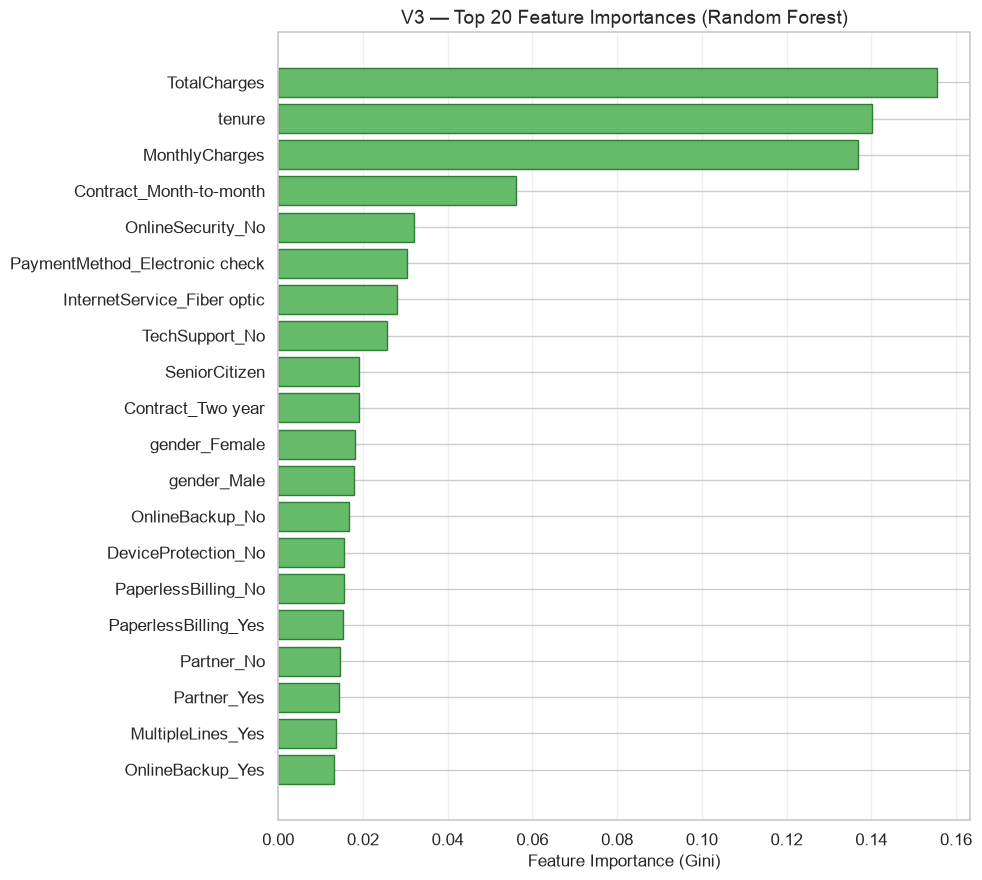

In [17]:
# ── Visualise top 20 features ─────────────────────────────────────────
top_n = 20
top_features = importance_df.head(top_n).copy()

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_features["feature"][::-1], top_features["importance"][::-1],
        color="#66BB6A", edgecolor="#2E7D32")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title(f"V3 — Top {top_n} Feature Importances (Random Forest)")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

---

## 13 · Logistic Regression vs Random Forest — Interpretability

### Logistic Regression (V1)
- **Coefficients** provide a clear directional signal: positive coefficient → pushes prediction toward churn, negative → toward non-churn.
- Each feature's contribution is additive and linear — easy to explain to stakeholders.
- Example: *"A one-standard-deviation increase in tenure decreases the log-odds of churn by X."*
- Limitation: Cannot capture nonlinear effects or interactions without manual feature engineering.

### Random Forest (V3)
- **Feature importance** tells us *which* features matter most for the ensemble's splits, but not *how* they relate to churn (no sign/direction).
- Naturally captures **nonlinear relationships** — e.g., tenure might matter differently at 1 month vs. 24 months.
- Naturally captures **feature interactions** — e.g., the combination of month-to-month contract + fiber optic internet may be more predictive than either feature alone.
- Limitation: Harder to explain individual predictions. Techniques like SHAP or partial dependence plots can help but are beyond V3 scope.

### Which is "more interpretable"?

For a stakeholder audience (e.g., a VP of Retention), Logistic Regression is easier to explain: *"These three factors push a customer toward churn."* Random Forest requires more effort to communicate but can capture subtler patterns.

Both models agree on some features being important (we can compare the top features from LR coefficients and RF importance), which strengthens our confidence in those features.

---

## 14 · Evidence for Nonlinearity

If Random Forest materially improves predictive performance over Logistic Regression on the same held-out test set, this provides evidence that the tree-based model may be capturing patterns — nonlinear relationships and/or feature interactions — that the linear model does not capture as effectively.

However, we must be careful:

1. **Performance improvement alone does not prove nonlinearity.** RF could outperform LR simply because it is a more flexible model, not because specific nonlinear patterns exist.
2. **We cannot identify which specific nonlinear patterns RF exploits** without further analysis (e.g., partial dependence plots, SHAP interaction values).
3. **If RF does NOT improve significantly**, this suggests the data may be approximately linear — Logistic Regression captures the important relationships, and the additional complexity of RF is unnecessary.

We let the actual metrics speak rather than making assumptions.

In [18]:
# ── Summary of performance difference ────────────────────────────────
auc_diff = auc_v3 - v1_metrics["roc_auc"]
f1_diff = f1_v3 - v1_metrics["f1_score"]

print("Performance difference (V3 − V1):")
print(f"  ROC-AUC: {auc_diff:+.4f}")
print(f"  F1:      {f1_diff:+.4f}")
print()

if abs(auc_diff) < 0.01:
    print("Interpretation: ROC-AUC difference is very small (< 0.01).")
    print("This suggests the overall discriminative ability is similar between")
    print("the linear and tree-based models on this dataset.")
elif auc_diff > 0.01:
    print("Interpretation: Random Forest shows a meaningful ROC-AUC improvement.")
    print("This provides evidence that nonlinear patterns or interactions may")
    print("be present and beneficial for prediction.")
else:
    print("Interpretation: Logistic Regression has a higher ROC-AUC.")
    print("The tree-based model may be overfitting or the relationships in")
    print("this dataset are well-captured by a linear model.")

Performance difference (V3 − V1):
  ROC-AUC: -0.0215
  F1:      -0.0713

Interpretation: Logistic Regression has a higher ROC-AUC.
The tree-based model may be overfitting or the relationships in
this dataset are well-captured by a linear model.


---

## 15 · Save Model Artifact

In [19]:
# ── Save V3 model ────────────────────────────────────────────────────
MODEL_DIR.mkdir(parents=True, exist_ok=True)

v3_model_path = MODEL_DIR / "churn_random_forest_v3.joblib"
joblib.dump(model_v3, v3_model_path)
print(f"✓ V3 model saved to: {v3_model_path}")
print(f"  File size: {v3_model_path.stat().st_size / 1024:.1f} KB")

# ── Verify prior models are untouched ────────────────────────────────
for fname in ["churn_baseline_v1.joblib", "churn_class_weighted_v2_2.joblib"]:
    path = MODEL_DIR / fname
    assert path.exists(), f"{fname} is missing!"
print(f"✓ V1 and V2.2 model files intact.")

✓ V3 model saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/models/churn_random_forest_v3.joblib
  File size: 56989.5 KB
✓ V1 and V2.2 model files intact.


---

## 16 · Save Metrics

In [20]:
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# ── Save V3 summary JSON ────────────────────────────────────────────
v3_summary = {
    "experiment": "V3 — Random Forest Baseline",
    "model": "RandomForestClassifier(n_estimators=300)",
    "model_artifact": str(v3_model_path),
    "random_state": RANDOM_STATE,
    "test_size": len(y_test),
    "train_size": len(y_train),
    "n_estimators": 300,
    "class_weight": None,
    "metrics_at_050": {
        "threshold": 0.50,
        "accuracy": round(acc_v3, 4),
        "precision": round(prec_v3, 4),
        "recall": round(rec_v3, 4),
        "f1": round(f1_v3, 4),
        "roc_auc": round(auc_v3, 4),
        "tp": int(tp_v3), "fp": int(fp_v3),
        "fn": int(fn_v3), "tn": int(tn_v3),
    },
}

json_path = METRICS_DIR / "random_forest_v3.json"
with open(json_path, "w") as f:
    json.dump(v3_summary, f, indent=2)
print(f"✓ V3 metrics saved to: {json_path}")

# ── Save feature importance CSV ──────────────────────────────────────
importance_csv_path = METRICS_DIR / "random_forest_feature_importance_v3.csv"
importance_df.to_csv(importance_csv_path, index=False)
print(f"✓ Feature importance saved to: {importance_csv_path}")

# ── Verify prior metric files ────────────────────────────────────────
for fname in ["baseline_v1.json", "threshold_analysis_v2_1.json",
              "threshold_analysis_v2_1.csv", "class_weighted_v2_2.json",
              "class_weighted_threshold_analysis_v2_2.csv",
              "feature_definitions_v1.json"]:
    assert (METRICS_DIR / fname).exists(), f"{fname} is missing!"
print(f"✓ All prior metric files intact.")

✓ V3 metrics saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/random_forest_v3.json
✓ Feature importance saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/random_forest_feature_importance_v3.csv
✓ All prior metric files intact.


---

## 17 · Reproducibility Check

We verify that the saved model artifact loads correctly and produces the same predictions.

In [21]:
# ── Load the saved model ──────────────────────────────────────────────
loaded_v3 = joblib.load(v3_model_path)

# ── Regenerate predictions ───────────────────────────────────────────
y_pred_loaded = loaded_v3.predict(X_test)
y_prob_loaded = loaded_v3.predict_proba(X_test)[:, 1]

# ── Compare ──────────────────────────────────────────────────────────
preds_match = np.array_equal(y_pred_v3, y_pred_loaded)
probs_match = np.allclose(y_prob_v3, y_prob_loaded)

print("Reproducibility check:")
print(f"  Predictions match : {'✓' if preds_match else '✗'}")
print(f"  Probabilities match: {'✓' if probs_match else '✗'}")

# ── Sample prediction ────────────────────────────────────────────────
sample = X_test.iloc[:1]
sample_pred = loaded_v3.predict(sample)[0]
sample_prob = loaded_v3.predict_proba(sample)[0]

print(f"\nSample prediction from loaded model:")
print(f"  Predicted class: {sample_pred} ({'Churn' if sample_pred == 1 else 'No Churn'})")
print(f"  P(No Churn)={sample_prob[0]:.4f}, P(Churn)={sample_prob[1]:.4f}")
print(f"  Actual label   : {y_test.iloc[0]}")
print(f"\n✓ V3 model artifact is valid and reproducible.")

Reproducibility check:
  Predictions match : ✓
  Probabilities match: ✓



Sample prediction from loaded model:
  Predicted class: 0 (No Churn)
  P(No Churn)=0.9967, P(Churn)=0.0033
  Actual label   : 0

✓ V3 model artifact is valid and reproducible.


---

## 18 · V3 Findings

In [22]:
print("=" * 70)
print("  IntelliPulse V3 — Random Forest Baseline Findings")
print("=" * 70)
print()

# 1. Accuracy
print(f"  1. Accuracy:")
print(f"     V1: {v1_metrics['accuracy']:.4f}  |  V3: {acc_v3:.4f}  "
      f"(Δ {acc_v3 - v1_metrics['accuracy']:+.4f})")
print(f"     → {'Improved' if acc_v3 > v1_metrics['accuracy'] else 'Decreased' if acc_v3 < v1_metrics['accuracy'] else 'Unchanged'}")
print()

# 2. Precision
print(f"  2. Precision:")
print(f"     V1: {v1_metrics['precision']:.4f}  |  V3: {prec_v3:.4f}  "
      f"(Δ {prec_v3 - v1_metrics['precision']:+.4f})")
print(f"     → {'Improved' if prec_v3 > v1_metrics['precision'] else 'Decreased' if prec_v3 < v1_metrics['precision'] else 'Unchanged'}")
print()

# 3. Recall
print(f"  3. Recall:")
print(f"     V1: {v1_metrics['recall']:.4f}  |  V3: {rec_v3:.4f}  "
      f"(Δ {rec_v3 - v1_metrics['recall']:+.4f})")
print(f"     → {'Improved' if rec_v3 > v1_metrics['recall'] else 'Decreased' if rec_v3 < v1_metrics['recall'] else 'Unchanged'}")
print()

# 4. F1
print(f"  4. F1-score:")
print(f"     V1: {v1_metrics['f1_score']:.4f}  |  V3: {f1_v3:.4f}  "
      f"(Δ {f1_v3 - v1_metrics['f1_score']:+.4f})")
print(f"     → {'Improved' if f1_v3 > v1_metrics['f1_score'] else 'Decreased' if f1_v3 < v1_metrics['f1_score'] else 'Unchanged'}")
print()

# 5. ROC-AUC
print(f"  5. ROC-AUC:")
print(f"     V1: {v1_metrics['roc_auc']:.4f}  |  V3: {auc_v3:.4f}  "
      f"(Δ {auc_v3 - v1_metrics['roc_auc']:+.4f})")
print(f"     → {'Improved' if auc_v3 > v1_metrics['roc_auc'] else 'Decreased' if auc_v3 < v1_metrics['roc_auc'] else 'Unchanged'}")
print()

# 6. Confusion matrix
print(f"  6. Confusion matrix change (V1 → V3):")
print(f"     Caught churners : {int(tp_v1)} → {int(tp_v3)} (Δ {int(tp_v3)-int(tp_v1):+d})")
print(f"     Missed churners : {int(fn_v1)} → {int(fn_v3)} (Δ {int(fn_v3)-int(fn_v1):+d})")
print(f"     False alarms    : {int(fp_v1)} → {int(fp_v3)} (Δ {int(fp_v3)-int(fp_v1):+d})")
print()

# 7. Top features
print(f"  7. Top 5 features by Random Forest importance:")
for _, row in importance_df.head(5).iterrows():
    print(f"     {row['feature']:35s} {row['importance']:.4f}")
print()

# 8. vs V2.1
print(f"  8. V3 vs V2.1 (threshold-tuned LR @ {v2_1_threshold}):")
print(f"     V2.1 Recall: {v2_1_metrics['recall']:.4f}  |  V3 Recall: {rec_v3:.4f}")
print(f"     V2.1 F1:     {v2_1_metrics['f1']:.4f}  |  V3 F1:     {f1_v3:.4f}")
print()

# 9. vs V2.2
print(f"  9. V3 vs V2.2 (class-weighted LR @ 0.50):")
print(f"     V2.2 Recall: {v2_2_metrics_050['recall']:.4f}  |  V3 Recall: {rec_v3:.4f}")
print(f"     V2.2 F1:     {v2_2_metrics_050['f1']:.4f}  |  V3 F1:     {f1_v3:.4f}")
print()

# 10. Justify further investigation?
print(f"  10. Assessment:")
if auc_v3 > v1_metrics["roc_auc"] + 0.005:
    print(f"      Random Forest shows a meaningful ROC-AUC improvement over")
    print(f"      Logistic Regression ({auc_v3:.4f} vs {v1_metrics['roc_auc']:.4f}).")
    print(f"      This justifies further investigation with hyperparameter tuning")
    print(f"      and threshold optimisation.")
elif abs(auc_v3 - v1_metrics["roc_auc"]) <= 0.005:
    print(f"      ROC-AUC is very similar ({auc_v3:.4f} vs {v1_metrics['roc_auc']:.4f}).")
    print(f"      The tree-based model does not show dramatically better")
    print(f"      discriminative ability, but may still offer advantages in specific")
    print(f"      metric trade-offs (precision/recall balance, confusion matrix).")
    print(f"      Further investigation with tuning and threshold analysis is")
    print(f"      warranted to determine if RF has untapped potential.")
else:
    print(f"      Logistic Regression has a higher ROC-AUC.")
    print(f"      The additional complexity of Random Forest may not be justified")
    print(f"      unless other metrics show clear advantages.")

print()
print("  ⚠  No final production model is declared yet.")
print()
print("─" * 70)

  IntelliPulse V3 — Random Forest Baseline Findings

  1. Accuracy:
     V1: 0.8055  |  V3: 0.7771  (Δ -0.0284)
     → Decreased

  2. Precision:
     V1: 0.6572  |  V3: 0.6007  (Δ -0.0565)
     → Decreased

  3. Recall:
     V1: 0.5588  |  V3: 0.4786  (Δ -0.0802)
     → Decreased

  4. F1-score:
     V1: 0.6040  |  V3: 0.5327  (Δ -0.0713)
     → Decreased

  5. ROC-AUC:
     V1: 0.8421  |  V3: 0.8206  (Δ -0.0215)
     → Decreased

  6. Confusion matrix change (V1 → V3):
     Caught churners : 209 → 179 (Δ -30)
     Missed churners : 165 → 195 (Δ +30)
     False alarms    : 109 → 119 (Δ +10)

  7. Top 5 features by Random Forest importance:
     TotalCharges                        0.1556
     tenure                              0.1401
     MonthlyCharges                      0.1368
     Contract_Month-to-month             0.0560
     OnlineSecurity_No                   0.0320

  8. V3 vs V2.1 (threshold-tuned LR @ 0.27):
     V2.1 Recall: 0.7834  |  V3 Recall: 0.4786
     V2.1 F1:     

### Final experiment table

In [23]:
final_table = pd.DataFrame({
    "Experiment": ["V1", "V2.1", "V2.2 @ 0.50",
                   f"V2.2 @ {v2_2_best_threshold}", "V3"],
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Class-weighted LR",
        "Class-weighted LR",
        "Random Forest",
    ],
    "Threshold": [0.50, v2_1_threshold, 0.50, v2_2_best_threshold, 0.50],
    "Accuracy": [
        v1_metrics["accuracy"], v2_1_metrics["accuracy"],
        v2_2_metrics_050["accuracy"], v2_2_metrics_best["accuracy"],
        round(acc_v3, 4),
    ],
    "Precision": [
        v1_metrics["precision"], v2_1_metrics["precision"],
        v2_2_metrics_050["precision"], v2_2_metrics_best["precision"],
        round(prec_v3, 4),
    ],
    "Recall": [
        v1_metrics["recall"], v2_1_metrics["recall"],
        v2_2_metrics_050["recall"], v2_2_metrics_best["recall"],
        round(rec_v3, 4),
    ],
    "F1": [
        v1_metrics["f1_score"], v2_1_metrics["f1"],
        v2_2_metrics_050["f1"], v2_2_metrics_best["f1"],
        round(f1_v3, 4),
    ],
    "ROC-AUC": [
        v1_metrics["roc_auc"], v1_metrics["roc_auc"],
        v2_2_metrics_050["roc_auc"], v2_2_metrics_best["roc_auc"],
        round(auc_v3, 4),
    ],
})

print("Final Experiment Table")
print("=" * 100)
print(final_table.to_string(index=False))
print()
print("Next: Investigate whether hyperparameter tuning, class weighting,")
print("and/or threshold optimisation can improve the Random Forest baseline.")
print("This will be decided after reviewing V3 results.")

Final Experiment Table
 Experiment               Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC
         V1 Logistic Regression       0.50    0.8055     0.6572  0.5588 0.6040   0.8421
       V2.1 Logistic Regression       0.27    0.7466     0.5149  0.7834 0.6214   0.8421
V2.2 @ 0.50   Class-weighted LR       0.50    0.7381     0.5043  0.7834 0.6136   0.8416
V2.2 @ 0.54   Class-weighted LR       0.54    0.7530     0.5238  0.7647 0.6217   0.8416
         V3       Random Forest       0.50    0.7771     0.6007  0.4786 0.5327   0.8206

Next: Investigate whether hyperparameter tuning, class weighting,
and/or threshold optimisation can improve the Random Forest baseline.
This will be decided after reviewing V3 results.


---

*End of IntelliPulse V3 — Random Forest Baseline*